In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg
from sklearn.decomposition import FastICA
import scipy.io as sio

# ======================== НАСТРОЙКИ ========================
np.random.seed(42)
N_CHANNELS = 10
N_TIMEPOINTS = 500
TIME_AXIS = np.arange(N_TIMEPOINTS)
AMP_1, FREQ_1 = 2.0, 0.05
AMP_2, FREQ_2 = 1.0, 0.10
PLOT_LIMIT = 100
VERT_OFFSET = 2.5

# Истинные паттерны (не менять)
spatial_1 = np.sin(np.linspace(0, 2*np.pi, N_CHANNELS))
spatial_2 = np.cos(np.linspace(0, 2*np.pi, N_CHANNELS))
temporal_1 = AMP_1 * np.sin(2*np.pi*FREQ_1*TIME_AXIS)
temporal_2 = AMP_2 * np.sin(2*np.pi*FREQ_2*TIME_AXIS)

# def generate_data(noise_level):
#     clean = np.outer(spatial_1, temporal_1) + np.outer(spatial_2, temporal_2)
#     noise = np.random.randn(N_CHANNELS, N_TIMEPOINTS) * noise_level
#     return clean + noise, clean, noise

def generate_data(noise_level):
    clean = np.outer(spatial_1, temporal_1) + np.outer(spatial_2, temporal_2)
    
    # 1. Генерируем независимый шум
    base_noise = np.random.randn(N_CHANNELS, N_TIMEPOINTS) * noise_level
    
    # 2. Создаем структуру шума (коррелируем каналы между собой)
    rng = np.random.RandomState(99) 
    noise_mixing_matrix = rng.randn(N_CHANNELS, N_CHANNELS)
    
    # Умножаем независимый шум на матрицу, делая его структурным
    structured_noise = noise_mixing_matrix @ base_noise 
    
    return clean + structured_noise, clean, structured_noise

def normalize_component(weights, temporal_pc, ref_signal=None, target_amp=None):
    scale = np.max(np.abs(weights))
    w_norm, t_norm = weights/scale, temporal_pc*scale
    if ref_signal is not None:
        if np.corrcoef(t_norm, ref_signal)[0,1] < 0:
            w_norm, t_norm = -w_norm, -t_norm
    if target_amp is not None and np.max(np.abs(t_norm)) > 0:
        t_norm = t_norm / np.max(np.abs(t_norm)) * target_amp
    return w_norm, t_norm

def plot_results(noisy_data, components, spatial_weights, titles, eigenvalues=None, plot_limit=100):
    # --- 1. Исходные данные ---
    n_chan = noisy_data.shape[0]
    fig, ax = plt.subplots(figsize=(8, 3))
    for ch in range(min(10, n_chan)): # Изменил на 10, чтобы видеть все каналы
        ax.plot(TIME_AXIS[:plot_limit], noisy_data[ch, :plot_limit] + ch * VERT_OFFSET, lw=0.8, alpha=0.7)
    ax.set_xlabel('Время'); ax.set_ylabel('Канал'); ax.set_title('Исходные данные'); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    # --- Матрица корреляций и График собственных значений ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Матрица корреляций
    corr_matrix = np.corrcoef(noisy_data)
    im = ax1.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
    fig.colorbar(im, ax=ax1)
    ax1.set_title('Корреляция каналов')
    ax1.set_xlabel('Каналы'); ax1.set_ylabel('Каналы')

    # График собственных значений (Scree Plot)
    if eigenvalues is not None:
        ax2.plot(range(1, len(eigenvalues) + 1), eigenvalues, 'o-', color='tab:red', ms=4)
        ax2.set_title('Собственные значения (Scree Plot)')
        ax2.set_xlabel('Номер компоненты')
        ax2.set_ylabel('Значение')
        ax2.grid(alpha=0.3)
    
    plt.tight_layout(); plt.show()

    # --- 3. Пространственные паттерны  ---
    fig, ax = plt.subplots(figsize=(6, 4))
    for w, lbl in zip(spatial_weights[:3], titles[:3]):
        ax.plot(np.arange(len(w)), w, marker='o', ms=3, label=lbl)
    ax.set_xlabel('Канал'); ax.set_ylabel('Вес'); ax.set_title('Пространственные паттерны'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    # --- 4. Временные компоненты  ---
    fig, ax = plt.subplots(figsize=(8, 4))
    for t, lbl in zip(components[:3], titles[:3]):
        ax.plot(TIME_AXIS[:plot_limit], t[:plot_limit], label=lbl, lw=1.5)
    ax.plot(TIME_AXIS[:plot_limit], temporal_1[:plot_limit], 'k--', label='Источник 1', alpha=0.7)
    ax.plot(TIME_AXIS[:plot_limit], temporal_2[:plot_limit], 'r--', label='Источник 2', alpha=0.7)
    ax.set_xlabel('Время'); ax.set_ylabel('Амплитуда'); ax.set_title('Временные компоненты'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()



=== ЗАДАНИЕ 1: PCA ===


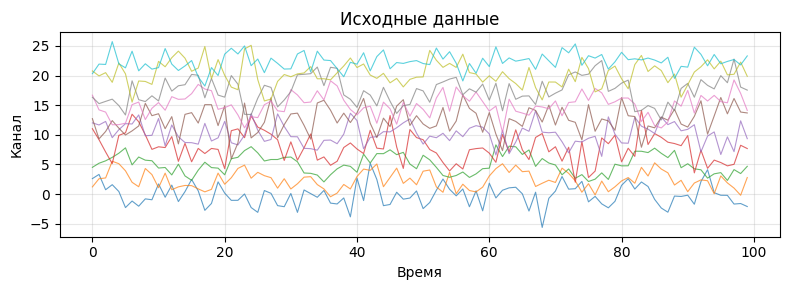

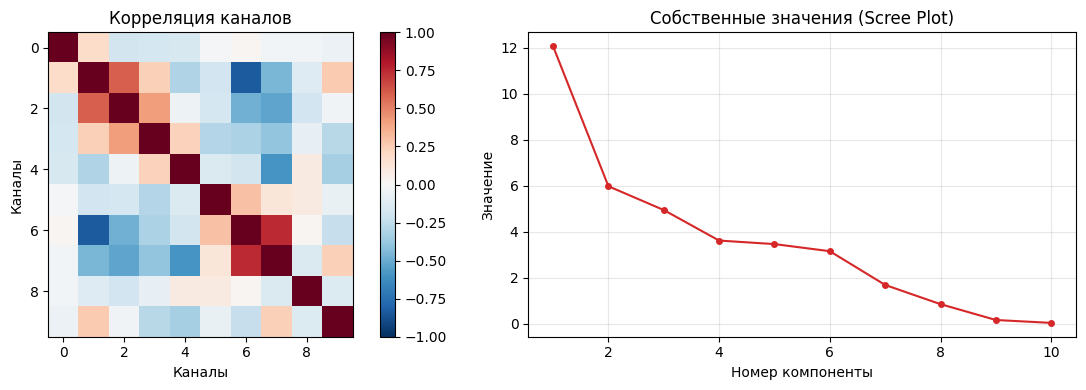

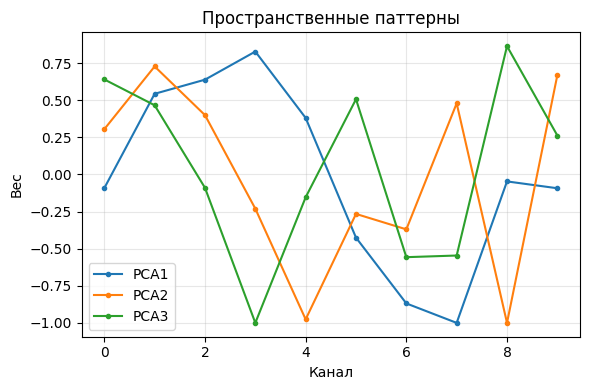

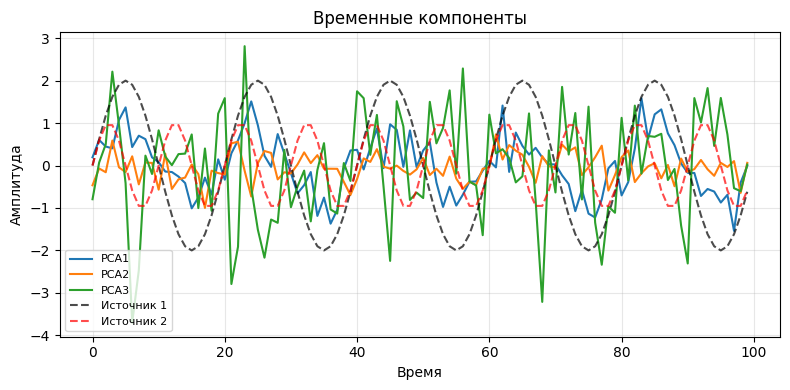

PCA: corr1 = 0.7911, corr2 = 0.3307


In [2]:
# ======================== ЗАДАНИЕ 1: PCA ========================
print("\n=== ЗАДАНИЕ 1: PCA ===")
NOISE_1 = 0.5 
noisy_1, clean_1, noise_1 = generate_data(NOISE_1)

# Центрирование
data_centered_1 = noisy_1 - np.mean(noisy_1, axis=1, keepdims=True)

# Ковариационная матрица
cov_matrix_1 = np.cov(data_centered_1)

# Собственные значения и векторы
eigenvalues_1, eigenvectors_1 = np.linalg.eigh(cov_matrix_1)

# Сортировка по убыванию
sorted_idx_1 = np.argsort(eigenvalues_1)[::-1]
eigenvalues_1 = eigenvalues_1[sorted_idx_1]
eigenvectors_1 = eigenvectors_1[:, sorted_idx_1]

# Проекция на компоненты
principal_components_1 = eigenvectors_1.T @ data_centered_1

# Визуализация
w1, t1 = normalize_component(eigenvectors_1[:,0], principal_components_1[0], temporal_1, AMP_1)
w2, t2 = normalize_component(eigenvectors_1[:,1], principal_components_1[1], temporal_2, AMP_2)
w3, t3 = normalize_component(eigenvectors_1[:,2], principal_components_1[2])

plot_results(noisy_1, [t1, t2, t3], [w1, w2, w3], ['PCA1', 'PCA2', 'PCA3'], eigenvalues=eigenvalues_1)

corr1_pca = np.abs(np.corrcoef(t1, temporal_1)[0,1])
corr2_pca = np.abs(np.corrcoef(t2, temporal_2)[0,1])
print(f"PCA: corr1 = {corr1_pca:.4f}, corr2 = {corr2_pca:.4f}")



=== ЗАДАНИЕ 2: GED ===


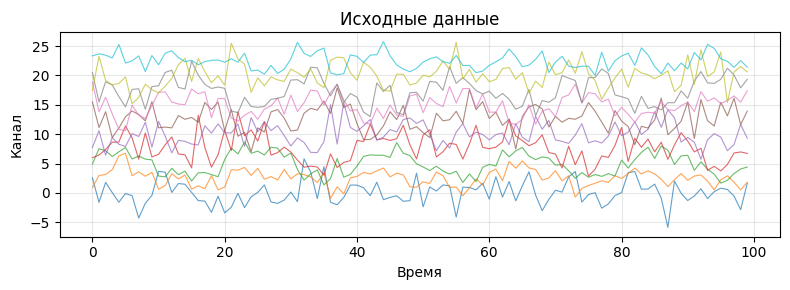

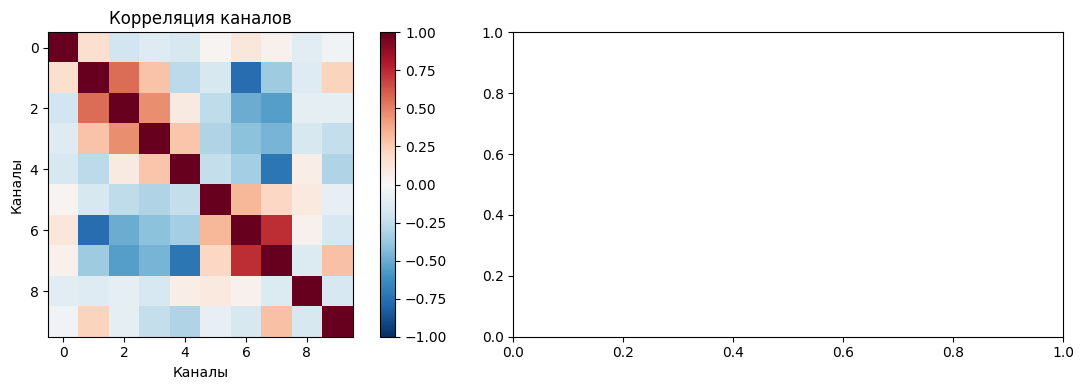

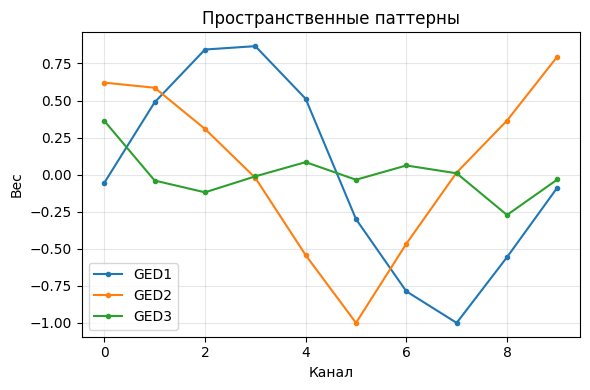

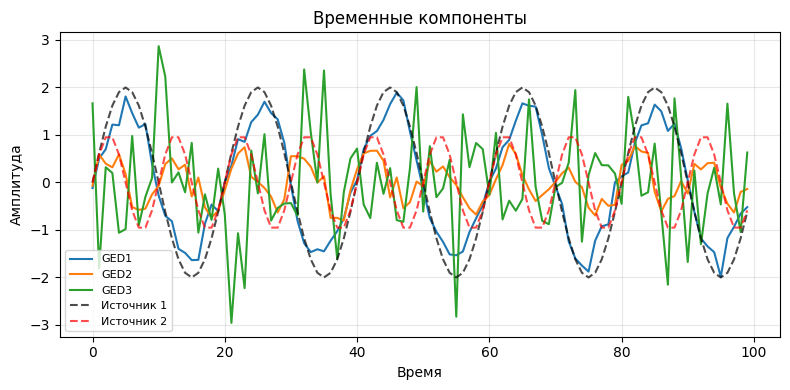

PCA: corr1 = 0.7911, corr2 = 0.3307
GED: corr1 = 0.9811, corr2 = 0.8318


In [3]:
# ======================== ЗАДАНИЕ 2: GED ========================
print("\n=== ЗАДАНИЕ 2: GED ===")
NOISE_2 = 0.5  
noisy_2, clean_2, noise_2 = generate_data(NOISE_2)

data_c_2 = noisy_2 - noisy_2.mean(axis=1, keepdims=True)
noise_c_2 = noise_2 - noise_2.mean(axis=1, keepdims=True)

# Ковариации
cov_sig_2 = np.cov(data_c_2)
cov_noise_2 = np.cov(noise_c_2)

# Регуляризация
reg = 1e-8 * np.trace(cov_noise_2) / N_CHANNELS
cov_noise_reg_2 = cov_noise_2 + reg * np.eye(N_CHANNELS)

# GED
evals_2, evecs_2 = scipy.linalg.eigh(cov_sig_2, cov_noise_reg_2)

# Сортировка
idx_ged = np.argsort(evals_2)[::-1]
evals_2 = evals_2[idx_ged]
evecs_2 = evecs_2[:, idx_ged]
comp_ts_2 = evecs_2.T @ data_c_2

# Форвард-модель (пространственный паттерн)
# def compute_forward(w, C_sig, C_noise):
#     denom = w.T @ C_noise @ w
#     return (C_sig @ w) / denom if np.abs(denom) > 1e-12 else np.zeros_like(w)

def compute_forward(w, C_sig, C_noise):
    denom = w.T @ C_noise @ w
    if np.abs(denom) < 1e-12:
        return np.zeros_like(w)
    return (C_sig @ w) / denom

C_sig_diff_2 = cov_sig_2 - cov_noise_2
f1 = compute_forward(evecs_2[:,0], C_sig_diff_2, cov_noise_reg_2)
f2 = compute_forward(evecs_2[:,1], C_sig_diff_2, cov_noise_reg_2)

w1g, t1g = normalize_component(f1, comp_ts_2[0], temporal_1, AMP_1)
w2g, t2g = normalize_component(f2, comp_ts_2[1], temporal_2, AMP_2)
# plot_results(noisy_2, [t1g,t2g,comp_ts_2[2]], [w1g,w2g,evecs_2[:,2]], ['GED1','GED2','GED3'])

plot_results(noisy_2, [t1g,t2g,comp_ts_2[2]], [w1g,w2g,evecs_2[:,2]], ['GED1','GED2','GED3'])

corr1_ged = np.abs(np.corrcoef(t1g, temporal_1)[0,1])
corr2_ged = np.abs(np.corrcoef(t2g, temporal_2)[0,1])
print(f"PCA: corr1 = {corr1_pca:.4f}, corr2 = {corr2_pca:.4f}")
print(f"GED: corr1 = {corr1_ged:.4f}, corr2 = {corr2_ged:.4f}")


Чтобы GED выиграл у PCA, шум должен быть пространственно коррелированным (или «структурированным»).

### Алгоритм GED:

1. Данные центрируем (вычитая среднее по времени), дисперсию к едингице не преиводим! (это исказит физический смысл, получаемый с датчиков)
2. Берём матрицы шума и сигнала.
Матрица шума ($C_{noise}$):$$C_{noise} = \begin{pmatrix} 2 & 1 & 0 & 0 & 0 \\ 1 & 2 & 0 & 0 & 0 \\ 0 & 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 0 & 1 \end{pmatrix}$$Что это значит? На каналах 1 и 2 есть шум. Их индивидуальная дисперсия равна 2, и они положительно коррелируют между собой (ковариация = 1). То есть шум бьет по обоим каналам одновременно в одном направлении.Матрица сигнала ($C_{signal}$):$$C_{signal} = \begin{pmatrix} 6 & -3 & 0 & 0 & 0 \\ -3 & 6 & 0 & 0 & 0 \\ 0 & 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 0 & 1 \end{pmatrix}$$ Что это значит? Когда включился полезный сигнал, дисперсия на каналах 1 и 2 выросла до 6, но их взаимосвязь стала отрицательной (-3). Это значит, что полезный источник качает эти каналы в противофазе (на одном канале плюс, на другом — минус).

Шаг алгоритма GED:Мы ищем такой вектор весов $\mathbf{w}$, который решит уравнение:$$\det(C_{signal} - \lambda C_{noise}) = 0$$Где $\lambda$ — это и есть наше отношение сигнал/шум (SNR), которое мы максимизируем.

Подставим наши числа для блока 1-го и 2-го каналов:$$\det \begin{pmatrix} 6 - 2\lambda & -3 - \lambda \\ -3 - \lambda & 6 - 2\lambda \end{pmatrix} = 0$$

Отсюда получаем два собственных значения (два SNR):

* $\lambda_1 = 9$ (Отношение сигнал/шум равно 9!)

* $\lambda_2 = 1$ (Сигнал равен шуму)

Ищем пространственный фильтр $\mathbf{w}$ для максимального $\lambda = 9$:Подставляем $\lambda = 9$ обратно в уравнение матрицы:$$\begin{pmatrix} 6 - 18 & -3 - 9 \\ -3 - 9 & 6 - 18 \end{pmatrix} \mathbf{w} = \begin{pmatrix} -12 & -12 \\ -12 & -12 \end{pmatrix} \begin{pmatrix} w_1 \\ w_2 \end{pmatrix} = 0$$Это дает нам простейшее уравнение: $-12w_1 - 12w_2 = 0 \implies w_1 = -w_2$.

Базовый вектор: $\mathbf{w} = [1, -1, 0, 0, 0]^T$.

Вектор $\mathbf{w}$ применяется ко всем каналам сразу с помощью обычного линейного взвешенного суммирования (матричного умножения).Если у нас есть матрица зашумленных данных $X$ размером $5 \times 1000$ (5 каналов, 1000 точек) и мы нашли вектор весов для первой компоненты $\mathbf{w}_1 = [1, -1, 0, 0, 0]^T$ (размером $5 \times 1$), то чистый временной ряд этой компоненты $y_1(t)$ вычисляется как:$$y_1(t) = \mathbf{w}_1^T X$$

То есть вектор $\mathbf{w}$ работает как пространственный фильтр. Он «схлопывает» 5 реальных физических каналов в 1 новый «виртуальный» канал (компоненту), в котором шум уничтожен за счет вычитания каналов друг из друга.Если мы возьмем несколько векторов $\mathbf{w}$ (например, для двух наибольших собственных значений) и соберем их в матрицу $W = [\mathbf{w}_1, \mathbf{w}_2]$, то получим сразу два очищенных источника: $Y = W^T X$.




=== ЗАДАНИЕ 3: ICA ===


d:\code\DPoS\.venv\Lib\site-packages\sklearn\decomposition\_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


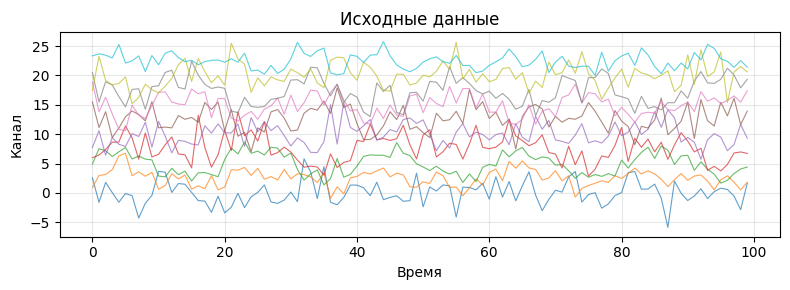

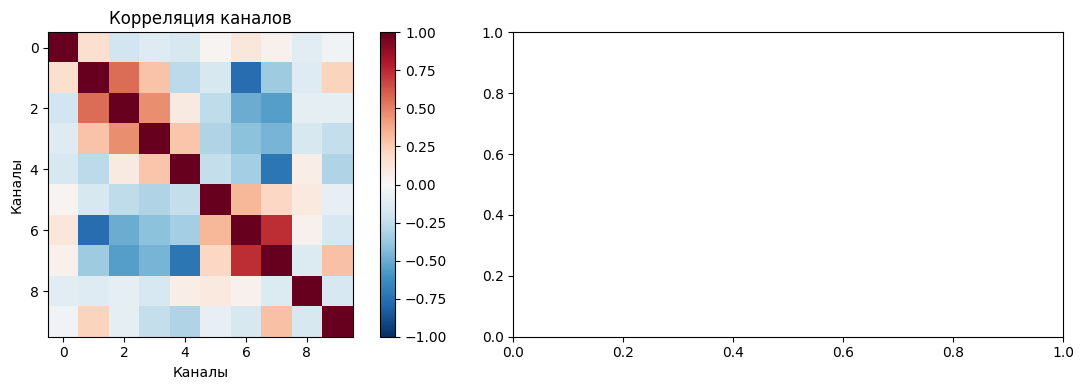

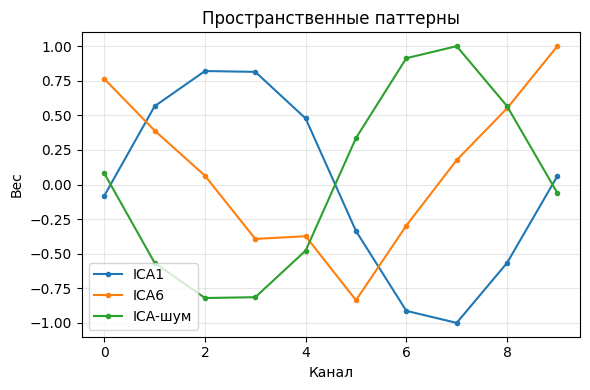

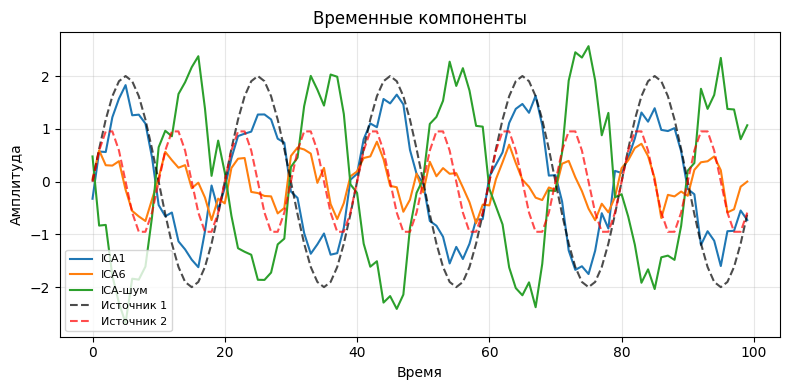

PCA: corr1 = 0.7911, corr2 = 0.3307
GED: corr1 = 0.9811, corr2 = 0.8318
ICA: corr1 = 0.9727, corr2 = 0.7883


In [4]:
# ======================== ЗАДАНИЕ 3: ICA ========================
print("\n=== ЗАДАНИЕ 3: ICA ===")
X_ica_input = noisy_2 - noisy_2.mean(axis=1, keepdims=True)
X_ica = X_ica_input.T 

# FastICA
ica = FastICA(n_components=N_CHANNELS, random_state=42, whiten='arbitrary-variance')
sources = ica.fit_transform(X_ica).T  # Транспонируем в (компоненты, время)
spatial_maps = ica.mixing_.T

# Сортировка по энергии
energy = np.sum(spatial_maps**2, axis=1)
sorted_idx = np.argsort(energy)[::-1]
spatial_maps = spatial_maps[sorted_idx]
sources = sources[sorted_idx]

# Поиск соответствия компонентам (максимальная корреляция)
corrs1 = [np.abs(np.corrcoef(s, temporal_1)[0,1]) for s in sources]
corrs2 = [np.abs(np.corrcoef(s, temporal_2)[0,1]) for s in sources]
idx1, idx2 = np.argmax(corrs1), np.argmax(corrs2)

# ИСПРАВЛЕНИЕ 1: Правильный порядок w (пространство) и t (время)
w1i, t1i = normalize_component(spatial_maps[idx1], sources[idx1], temporal_1, AMP_1)
w2i, t2i = normalize_component(spatial_maps[idx2], sources[idx2], temporal_2, AMP_2)

# ИСПРАВЛЕНИЕ 2: Нормализуем также и шумовую компоненту для корректного отображения масштаба
w3i, t3i = normalize_component(spatial_maps[0], sources[0])

# Передаем правильные t и w
plot_results(noisy_2, [t1i, t2i, t3i], 
             [w1i, w2i, w3i], [f'ICA{idx1+1}', f'ICA{idx2+1}', 'ICA-шум'])

corr1_ica = np.abs(np.corrcoef(t1i, temporal_1)[0,1])
corr2_ica = np.abs(np.corrcoef(t2i, temporal_2)[0,1])
print(f"PCA: corr1 = {corr1_pca:.4f}, corr2 = {corr2_pca:.4f}")
print(f"GED: corr1 = {corr1_ged:.4f}, corr2 = {corr2_ged:.4f}")
print(f"ICA: corr1 = {corr1_ica:.4f}, corr2 = {corr2_ica:.4f}")

### Алгоритм ICA
### 1. «Отбеливание» (Whitening). Для n каналов нам нужно сделать так, чтобы они одновременно имели дисперсию = 1 и не коррелировали между собой (матрица ковариации должна стать идеально единичной $I$).

Делается это с помощью PCA:
1. Считаем ковариационную матрицу данных $C$. 
2. Делаем её собственное разложение: $C = E D E^T$, где $E$ — матрица собственных векторов (поворот), а $D$ — диагональная матрица собственных значений (дисперсии вдоль новых осей).
3. Матрица отбеливания считается как: $W_{white} = D^{-1/2} E^T$.
4. Умножаем её на данные: $X_{white} = W_{white} X$.

Что произошло геометрически? Операция $E^T X$ повернула наше облако точек так, что оси стали некоррелированными (это стандартный PCA). А умножение на $D^{-1/2}$ сжало или растянуло облако по каждой из этих осей, превратив вытянутый «эллипс» данных в идеальный круг (сферу), где дисперсия в любом направлении равна 1.

### 2. Истинные независимые сигналы (которые мы хотим найти)

Пусть идеальные скрытые данные — это бинарные сигналы (например, прямоугольные импульсы):$s_1 = [1, -1, 1, -1]$$s_2 = [1, 1, -1, -1]$

Посчитаем математическую негауссовость (эксцесс/куртозис) для сигнала $s_1$. Формула эксцесса при среднем = 0 и дисперсии = 1: 

$K = E[s^4] - 3$.

Возводим точки в 4-ю степень: $1^4 = 1, (-1)^4 = 1 \dots$ 

Все четвертые степени равны 1. Среднее четвертых степеней: $E[s_1^4] = (1 + 1 + 1 + 1) / 4 = 1$. Эксцесс: $K(s_1) = 1 - 3 = \mathbf{-2}$. (Это сильное отличие от Гауссианы, у которой эксцесс равен 0).

### 3: Реальные сигналы

Мы не видим $s_1$ и $s_2$. Они смешались в пространстве, например, повернувшись на 45 градусов друг относительно друга. Прибор записал смесь $x_1$:$$x_1 = \frac{1}{\sqrt{2}}s_1 + \frac{1}{\sqrt{2}}s_2 \approx 0.707 \cdot s_1 + 0.707 \cdot s_2$$

Давай посчитаем значения этой смеси $x_1$ в наших 4 точках времени:

* Точка 1: $0.707(1) + 0.707(1) = 1.414$
* Точка 2: $0.707(-1) + 0.707(1) = 0$
* Точка 3: $0.707(1) + 0.707(-1) = 0$...
* в итоге получаем вектор смеси: $x_1 = [1.414, 0, 0, -1.414]$

### 4 Как ICA находит решение?
ICA начинает крутить оси координат и мерить эксцесс получающейся проекции. Посчитаем эксцесс для этой смеси $x_1$:
* Дисперсия смеси осталась равной 1 ( $(1.414^2 + 0 + 0 + (-1.414)^2)/4 = (2 + 2)/4 = 1$ ).
* Возводим точки смеси в 4-ю степень: $1.414^4 = 4$, $0^4 = 0$, $(-1.414)^4 = 4$.
* Среднее четвертых степеней: $E[x_1^4] = (4 + 0 + 0 + 4) / 4 = 2$.
* Вычисляем эксцесс смеси: $K(x_1) = 2 - 3 = \mathbf{-1}$.

### 5 Финал работы ICA 
Эксцесс чистого источника = $\mathbf{-2}$

Эксцесс смеси = $\mathbf{-1}$ 

(он стал ближе к 0, то есть смесь стала более «гауссовской», распределение стало более гладким из-за появления нулей).Алгоритм FastICA берет смесь $x_1$ (у которой эксцесс $-1$), начинает математически «вращать» её систему координат в 5-мерном пространстве и видит, что при определенном угле поворота эксцесс начинает уходить от нуля и падает до $-2$.Как только алгоритм нащупал точку, где абсолютное значение эксцесса стало максимально возможным (в нашем случае $|-2|$), он останавливается.